**Problem Definition**

Main Problem

Predict traffic volume/congestion using historical traffic data.

Questions
What times have highest congestion?
Which factors affect traffic most?
Can machine learning accurately predict traffic flow?
Hypothesis

Traffic congestion depends on the Time and Day

In [2]:
#Data Collection
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("hasibullahaman/traffic-prediction-dataset")

print(path)
print(os.listdir(path))

/Users/youssefbarakat/tensorflow_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 83.1k/83.1k [00:00<00:00, 392kB/s]

Extracting files...
/Users/youssefbarakat/.cache/kagglehub/datasets/hasibullahaman/traffic-prediction-dataset/versions/2
['Traffic.csv', 'TrafficTwoMonth.csv']


In [3]:
df1 = pd.read_csv(os.path.join(path, "Traffic.csv"))
df2 = pd.read_csv(os.path.join(path, "TrafficTwoMonth.csv"))

In [4]:
#Data Cleaning & Preparation
#df1[:10]
#df2[:10]
df = pd.concat([df1, df2], ignore_index=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df[:10]

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal
5,1:15:00 AM,10,Tuesday,44,0,5,4,53,low
6,1:30:00 AM,10,Tuesday,37,0,1,4,42,low
7,1:45:00 AM,10,Tuesday,42,4,4,5,55,low
8,2:00:00 AM,10,Tuesday,51,0,9,7,67,low
9,2:15:00 AM,10,Tuesday,34,0,4,7,45,low


In [5]:
df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

In [6]:
import numpy as np
for col in df.columns:
    null_indices = np.random.choice(df.index, 10, replace=False)
    df.loc[null_indices, col] = np.nan
df.isnull().sum()

Time                 10
Date                 10
Day of the week      10
CarCount             10
BikeCount            10
BusCount             10
TruckCount           10
Total                10
Traffic Situation    10
dtype: int64

In [7]:
df.dropna(inplace=True)
df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

In [8]:
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,6234.000000,6234.000000,6234.000000,6234.000000,6234.000000,6234.000000
mean,16.019410,64.372955,12.007058,12.551171,18.629291,107.560475
std,8.956162,44.309806,11.339259,12.322451,10.696597,55.858812
min,1.000000,5.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,18.000000,3.000000,1.000000,10.000000,53.000000
50%,16.000000,61.000000,9.000000,10.000000,18.000000,103.000000
75%,24.000000,102.000000,18.750000,20.000000,27.000000,151.000000
max,31.000000,180.000000,70.000000,50.000000,60.000000,278.000000


In [9]:
#Exploratory Data Analysis (EDA)
df.info()
df.describe()
print(df.shape)

<class 'pandas.DataFrame'>
Index: 6234 entries, 0 to 6323
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               6234 non-null   str    
 1   Date               6234 non-null   float64
 2   Day of the week    6234 non-null   str    
 3   CarCount           6234 non-null   float64
 4   BikeCount          6234 non-null   float64
 5   BusCount           6234 non-null   float64
 6   TruckCount         6234 non-null   float64
 7   Total              6234 non-null   float64
 8   Traffic Situation  6234 non-null   str    
dtypes: float64(6), str(3)
memory usage: 487.0 KB
(6234, 9)


In [10]:
avg_day = df.groupby("Day of the week")["Total"].mean()

print(avg_day)

Day of the week
Friday       102.561576
Monday       107.744681
Saturday     108.259533
Sunday       109.405439
Thursday     107.722112
Tuesday      108.075226
Wednesday    108.736000
Name: Total, dtype: float64


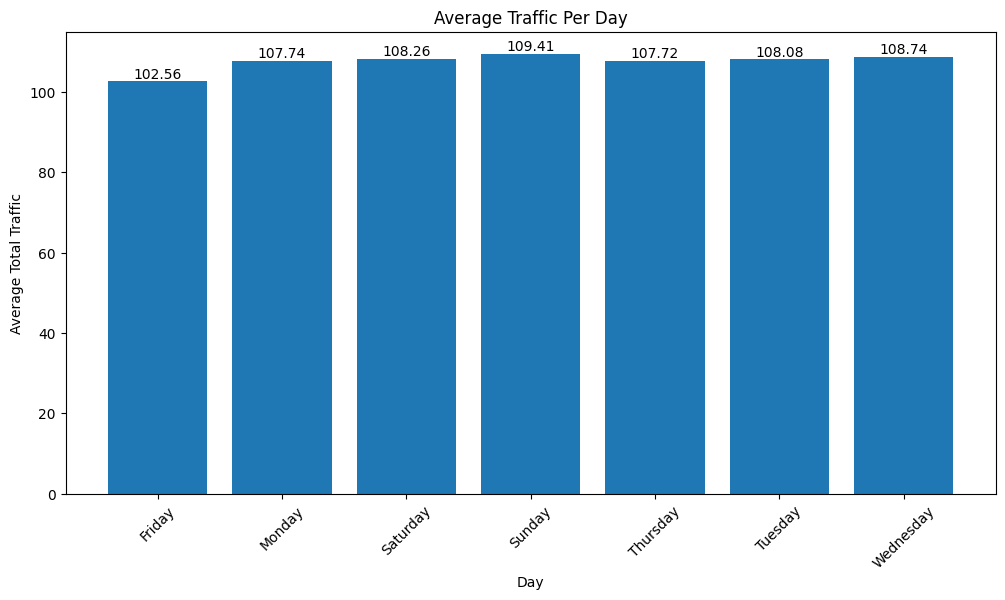

In [11]:
import matplotlib.pyplot as plt

avg_traffic = df.groupby("Day of the week")["Total"].mean()

plt.figure(figsize=(12, 6))

bars = plt.bar(avg_traffic.index, avg_traffic.values)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval, 2),
        ha='center',
        va='bottom'
    )

plt.xlabel("Day")
plt.ylabel("Average Total Traffic")
plt.title("Average Traffic Per Day")

plt.xticks(rotation=45)

plt.show()

In [12]:
sns.lineplot(x='Date',
             y='Total',
             data=df)
plt.show()

NameError: name 'sns' is not defined

In [13]:
sns.lineplot(x='Day of the week',y='Total',data=df)
plt.show()
sns.lineplot(x='Total',y='Day of the week',data=df)
plt.show()

NameError: name 'sns' is not defined

In [14]:
print(df.corr(numeric_only=True))

                Date  CarCount  BikeCount  BusCount  TruckCount     Total
Date        1.000000 -0.010984  -0.003944 -0.006213    0.020259 -0.007005
CarCount   -0.010984  1.000000   0.705999  0.664933   -0.583796  0.971454
BikeCount  -0.003944  0.705999   1.000000  0.582749   -0.586394  0.779293
BusCount   -0.006213  0.664933   0.582749  1.000000   -0.533941  0.764107
TruckCount  0.020259 -0.583796  -0.586394 -0.533941    1.000000 -0.508425
Total      -0.007005  0.971454   0.779293  0.764107   -0.508425  1.000000


In [15]:
df['Time'] = pd.to_datetime(df['Time'])

df['Time'] = (
    df['Time'].dt.hour +
    df['Time'].dt.minute / 60
)
df['Time']

/var/folders/ph/90hk2k6939q3csdkd211f59c0000gn/T/ipykernel_26615/2675767876.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


0        0.00
1        0.25
2        0.50
3        0.75
4        1.00
        ...  
6318     5.25
6319    10.50
6321    21.00
6322    21.50
6323    23.75
Name: Time, Length: 6234, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['Total', 'Traffic Situation', 'Day of the week'], axis=1)
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]]
y = df["Traffic Situation"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[233   0   0   0]
 [  0  66   0  18]
 [  0   0 121  47]
 [  0  36  39 687]]


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Traffic_Label"] = encoder.fit_transform(df["Traffic Situation"])

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Encode labels
encoder = LabelEncoder()

df["Traffic_Label"] = encoder.fit_transform(df["Traffic Situation"])

# Features
X = df[["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]]

# Target
y = df["Traffic_Label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = RandomForestClassifier()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)


print("MAE:", mae)
print("MSE:", mse)

MAE: 0.15156375300721733
MSE: 0.23496391339214115


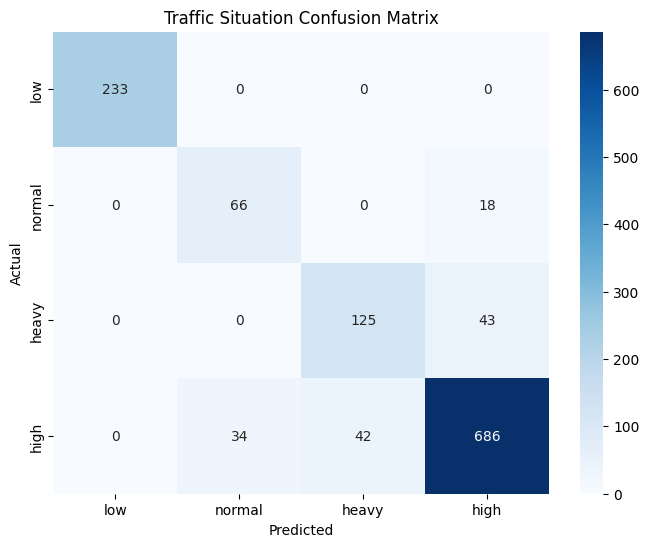

In [ ]:
labels = df["Traffic Situation"].unique()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Traffic Situation Confusion Matrix")

plt.show()